In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Sample - Superstore.csv", encoding="latin1")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Dataset ki basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
# Har column mein missing values
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
# Duplicate rows check
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [ ]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df[["Order Date", "Ship Date", "Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [ ]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Quantity:", total_quantity)

Total Sales: 2297200.86
Total Profit: 286397.02
Total Quantity: 37873


In [ ]:
profit_margin = (total_profit / total_sales) * 100

print("Profit Margin:", round(profit_margin, 2), "%")

Profit Margin: 12.47 %


In [ ]:
category_analysis = df.groupby("Category")[["Sales", "Profit"]].sum()

category_analysis


,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


In [ ]:
category_discount = df.groupby("Category")[["Discount", "Profit"]].mean()

category_discount

,Discount,Profit
Category,,
Furniture,0.173923,8.699327
Office Supplies,0.157285,20.327050
Technology,0.132323,78.752002


In [ ]:
discount_profit = df.groupby("Discount")["Profit"].mean()

discount_profit

,Profit
Discount,
0.00,66.900292
0.10,96.055074
0.15,27.288298
0.20,24.702572
0.30,-45.679636
0.32,-88.560656
0.40,-111.927429
0.45,-226.646464
0.50,-310.703456


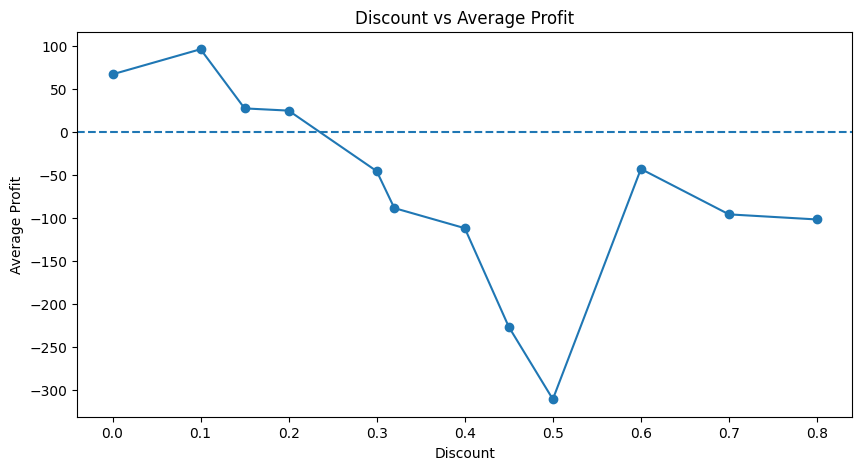

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(discount_profit.index, discount_profit.values, marker="o")

plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.title("Discount vs Average Profit")

plt.axhline(0, linestyle="--")

plt.show()

In [ ]:
region_analysis = df.groupby("Region")[["Sales", "Profit"]].sum()

region_analysis

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


In [ ]:
region_analysis["Profit Margin"] = (
    region_analysis["Profit"] / region_analysis["Sales"]
) * 100

region_analysis

,Sales,Profit,Profit Margin
Region,,,
Central,501239.8908,39706.3625,7.921629
East,678781.2400,91522.7800,13.483399
South,391721.9050,46749.4303,11.934342
West,725457.8245,108418.4489,14.944831


In [ ]:
df["Year"] = df["Order Date"].dt.year

yearly_analysis = df.groupby("Year")[["Sales", "Profit"]].sum()

yearly_analysis

,Sales,Profit
Year,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


In [ ]:
yearly_growth = yearly_analysis.pct_change() * 100

yearly_growth

,Sales,Profit
Year,,
2014,NaN,NaN
2015,-2.832227,24.371540
2016,29.471521,32.744284
2017,20.355962,14.235675


In [ ]:
top_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766
Ativa V4110MDD Micro-Cut Shredder,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,3696.2820
Ibico EPK-21 Electric Binding System,3345.2823


In [ ]:
bottom_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=True)
    .head(10)
)

bottom_products


,Profit
Product Name,
Cubify CubeX 3D Printer Double Head Print,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.1156
Bush Advantage Collection Racetrack Conference Table,-1934.3976
GBC DocuBind P400 Electric Binding System,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,-1811.0784
Martin Yale Chadless Opener Electric Letter Opener,-1299.1836
Balt Solid Wood Round Tables,-1201.0581


In [ ]:
segment_analysis = df.groupby("Segment")[["Sales", "Profit"]].sum()

segment_analysis

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


In [ ]:
segment_analysis["Profit Margin"] = (
    segment_analysis["Profit"] / segment_analysis["Sales"]
) * 100

segment_analysis

,Sales,Profit,Profit Margin
Segment,,,
Consumer,1.161401e+06,134119.2092,11.548050
Corporate,7.061464e+05,91979.1340,13.025506
Home Office,4.296531e+05,60298.6785,14.034269


In [ ]:
shipping_analysis=df.groupby("Ship Mode")["Shipping Days"].mean()
shipping_analysis

,Shipping Days
Ship Mode,
First Class,2.182705
Same Day,0.044199
Second Class,3.238046
Standard Class,5.006535


In [ ]:
shipping_profit=df.groupby("Ship Mode")[["Sales","Profit"]].sum()
shipping_profit

,Sales,Profit
Ship Mode,,
First Class,3.514284e+05,48969.8399
Same Day,1.283631e+05,15891.7589
Second Class,4.591936e+05,57446.6354
Standard Class,1.358216e+06,164088.7875


In [ ]:
state_analysis = (
    df.groupby("State")[["Sales", "Profit"]]
    .sum()
    .sort_values("Profit", ascending=False)
)

state_analysis.head(10)

,Sales,Profit
State,,
California,457687.6315,76381.3871
New York,310876.2710,74038.5486
Washington,138641.2700,33402.6517
Michigan,76269.6140,24463.1876
Virginia,70636.7200,18597.9504
Indiana,53555.3600,18382.9363
Georgia,49095.8400,16250.0433
Kentucky,36591.7500,11199.6966
Minnesota,29863.1500,10823.1874


In [ ]:
state_analysis = (
    df.groupby("State")[["Sales", "Profit"]]
    .sum()
    .sort_values("Profit", ascending=False)
)

state_analysis.head(10)

,Sales,Profit
State,,
California,457687.6315,76381.3871
New York,310876.2710,74038.5486
Washington,138641.2700,33402.6517
Michigan,76269.6140,24463.1876
Virginia,70636.7200,18597.9504
Indiana,53555.3600,18382.9363
Georgia,49095.8400,16250.0433
Kentucky,36591.7500,11199.6966
Minnesota,29863.1500,10823.1874


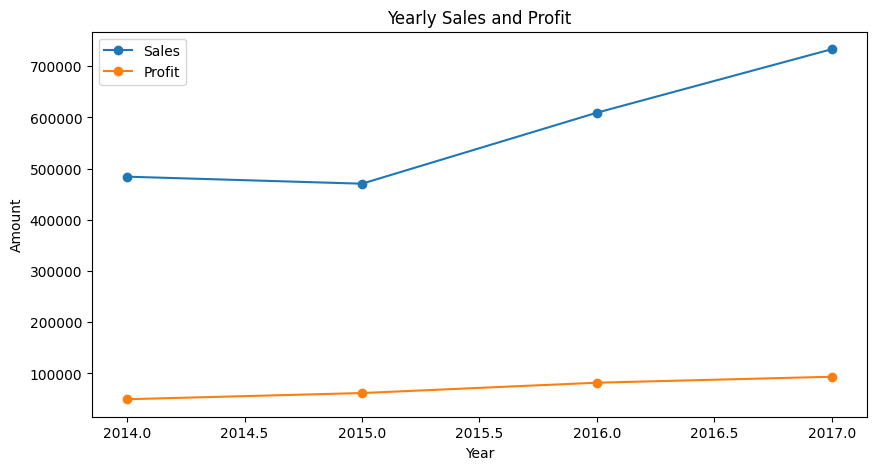

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(yearly_analysis.index, yearly_analysis["Sales"], marker="o", label="Sales")
plt.plot(yearly_analysis.index, yearly_analysis["Profit"], marker="o", label="Profit")

plt.xlabel("Year")
plt.ylabel("Amount")
plt.title("Yearly Sales and Profit")
plt.legend()

plt.show()

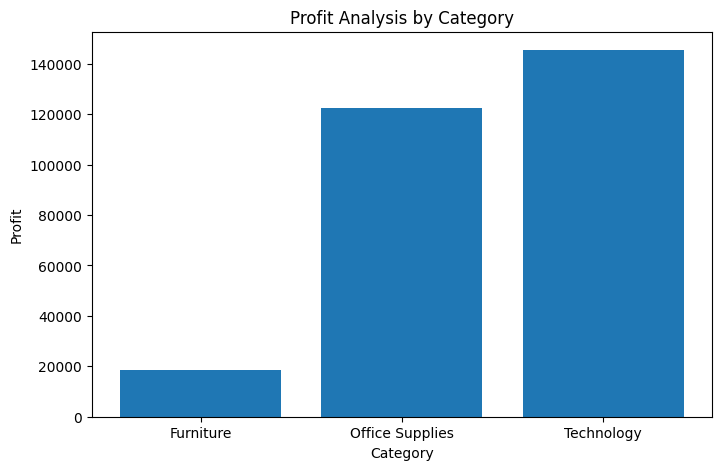

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(category_analysis.index, category_analysis["Profit"])
plt.xlabel("Category")
plt.ylabel("Profit")
plt.title("Profit Analysis by Category")
plt.show()

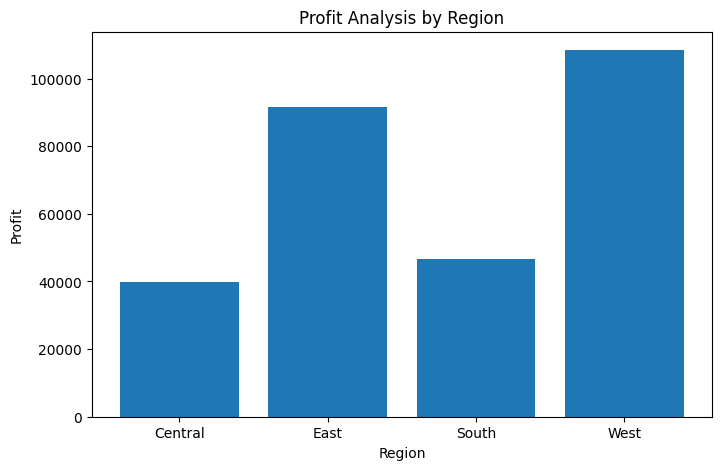

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(region_analysis.index,region_analysis["Profit"])
plt.xlabel("Region")
plt.ylabel("Profit")
plt.title("Profit Analysis by Region")
plt.show()


In [ ]:
import sqlite3

conn = sqlite3.connect("superstore.db")

df.to_sql("sales", conn, if_exists="replace", index=False)

print("SQL table created successfully!")

SQL table created successfully!


In [ ]:
query="""
select*from sales limit5;
"""
result=pd.read_sql_query(query,conn)
result

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Days,Year
0,1,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,2016
1,2,CA-2016-152156,2016-11-08 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,2016
2,3,CA-2016-138688,2016-06-12 00:00:00,2016-06-16 00:00:00,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,2016
3,4,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,2015
4,5,US-2015-108966,2015-10-11 00:00:00,2015-10-18 00:00:00,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21 00:00:00,2014-01-23 00:00:00,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,2,2014
9990,9991,CA-2017-121258,2017-02-26 00:00:00,2017-03-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,5,2017
9991,9992,CA-2017-121258,2017-02-26 00:00:00,2017-03-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,5,2017
9992,9993,CA-2017-121258,2017-02-26 00:00:00,2017-03-03 00:00:00,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,5,2017


In [ ]:
query="""
SELECT Category,SUM(Sales) AS Total_Sales,SUM(Profit) AS Total_Profit
FROM Sales
GROUP BY Category
ORDER BY Total_Profit desc;
"""
result=pd.read_sql_query(query,conn)
result

,Category,Total_Sales,Total_Profit
0,Technology,836154.0330,145454.9481
1,Office Supplies,719047.0320,122490.8008
2,Furniture,741999.7953,18451.2728


In [ ]:
query = """
SELECT
    Region,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Region
ORDER BY Total_Profit DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Region,Total_Sales,Total_Profit
0,West,725457.8245,108418.4489
1,East,678781.2400,91522.7800
2,South,391721.9050,46749.4303
3,Central,501239.8908,39706.3625


In [ ]:
query = """
SELECT
    "Product Name",
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY "Product Name"
ORDER BY Total_Profit DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result

,Product Name,Total_Profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
2,Hewlett Packard LaserJet 3310 Copier,6983.8836
3,Canon PC1060 Personal Laser Copier,4570.9347
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.9766
5,Ativa V4110MDD Micro-Cut Shredder,3772.9461
6,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
7,Plantronics Savi W720 Multi-Device Wireless He...,3696.2820
8,Ibico EPK-21 Electric Binding System,3345.2823
9,Zebra ZM400 Thermal Label Printer,3343.5360


In [ ]:
query = """
SELECT
    "Product Name",
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY "Product Name"
ORDER BY Total_Profit ASC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result

,Product Name,Total_Profit
0,Cubify CubeX 3D Printer Double Head Print,-8879.9704
1,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
2,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.1156
4,Bush Advantage Collection Racetrack Conference...,-1934.3976
5,GBC DocuBind P400 Electric Binding System,-1878.1662
6,Cisco TelePresence System EX90 Videoconferenci...,-1811.0784
7,Martin Yale Chadless Opener Electric Letter Op...,-1299.1836
8,Balt Solid Wood Round Tables,-1201.0581
9,BoxOffice By Design Rectangular and Half-Moon ...,-1148.4375


In [ ]:
query = """
SELECT
    "Order Date",
    Sales,
    Profit
FROM sales
LIMIT 5;
"""

result = pd.read_sql_query(query, conn)

result

,Order Date,Sales,Profit
0,2016-11-08 00:00:00,261.9600,41.9136
1,2016-11-08 00:00:00,731.9400,219.5820
2,2016-06-12 00:00:00,14.6200,6.8714
3,2015-10-11 00:00:00,957.5775,-383.0310
4,2015-10-11 00:00:00,22.3680,2.5164


In [ ]:
query = """
SELECT
    strftime('%Y', "Order Date") AS Year,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY strftime('%Y', "Order Date")
ORDER BY Year;
"""

result = pd.read_sql_query(query, conn)

result

,Year,Total_Sales,Total_Profit
0,2014,484247.4981,49543.9741
1,2015,470532.5090,61618.6037
2,2016,609205.5980,81795.1743
3,2017,733215.2552,93439.2696


In [ ]:
query = """
SELECT
    Segment,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Segment
ORDER BY Total_Profit DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Segment,Total_Sales,Total_Profit
0,Consumer,1.161401e+06,134119.2092
1,Corporate,7.061464e+05,91979.1340
2,Home Office,4.296531e+05,60298.6785


In [ ]:
query = """
SELECT
    "Ship Mode",
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY "Ship Mode"
ORDER BY Total_Profit DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Ship Mode,Total_Sales,Total_Profit
0,Standard Class,1.358216e+06,164088.7875
1,Second Class,4.591936e+05,57446.6354
2,First Class,3.514284e+05,48969.8399
3,Same Day,1.283631e+05,15891.7589


In [ ]:
query = """
SELECT
    Discount,
    AVG(Profit) AS Average_Profit
FROM sales
GROUP BY Discount
ORDER BY Discount;
"""

result = pd.read_sql_query(query, conn)

result

,Discount,Average_Profit
0,0.00,66.900292
1,0.10,96.055074
2,0.15,27.288298
3,0.20,24.702572
4,0.30,-45.679636
5,0.32,-88.560656
6,0.40,-111.927429
7,0.45,-226.646464
8,0.50,-310.703456
9,0.60,-43.077212
